In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [62]:
X = pd.read_csv('ecommerce_customer_features.csv').drop(["Customer_ID"], axis=1)
Y = pd.read_csv('ecommerce_customer_targets.csv').drop(["Customer_ID"], axis=1)

X.head()



,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


In [63]:
# convert categorical variable into binary
lb = LabelEncoder()
Y['churned'] = lb.fit_transform(Y['churned'])
X['loyalty_member']= lb.fit_transform(X['loyalty_member'])


In [64]:
print(X.isnull().sum())
print(Y.isnull().sum())

account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
dtype: int64
churned    0
dtype: int64


In [65]:
# train test split 

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

num_cols = [col for col in X.columns if col != 'loyalty_member']

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

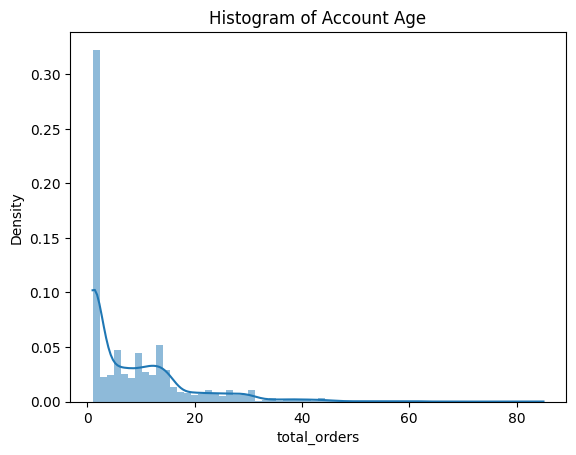

In [67]:
sns.histplot(X['total_orders'], kde=True, stat="density", linewidth=0)
plt.title('Histogram of Account Age')
plt.show()

In [ ]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
num_cols = ['account_age_months', 'avg_order_value', 'total_orders', 
            'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 
            'customer_support_tickets', 'browsing_frequency_per_week', 
            'cart_abandonment_rate', 'product_review_score_avg', 
            'engagement_score', 'satisfaction_score', 'price_sensitivity_index']

# Fit and transform the data
X[num_cols] = qt.fit_transform(X[num_cols])

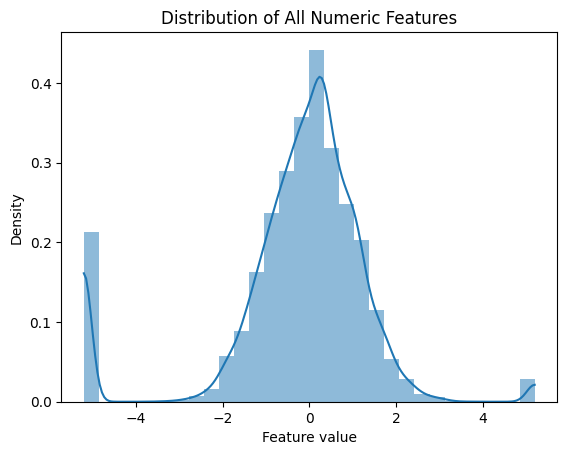

In [ ]:
numeric_values = X[num_cols].melt(value_vars=num_cols)['value']

sns.histplot(
    numeric_values,
    kde=True,
    stat="density",
    linewidth=0,
    bins=30,
)
plt.title('Distribution of All Numeric Features')
plt.xlabel('Feature value')
plt.ylabel('Density')
plt.show()

In [70]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train.values.ravel()) # .values.ravel() removes a sklearn warning
y_pred = model.predict(x_test_scaled)

accuracy score:  0.9741666666666666
classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1007
           1       0.94      0.90      0.92       193

    accuracy                           0.97      1200
   macro avg       0.96      0.94      0.95      1200
weighted avg       0.97      0.97      0.97      1200



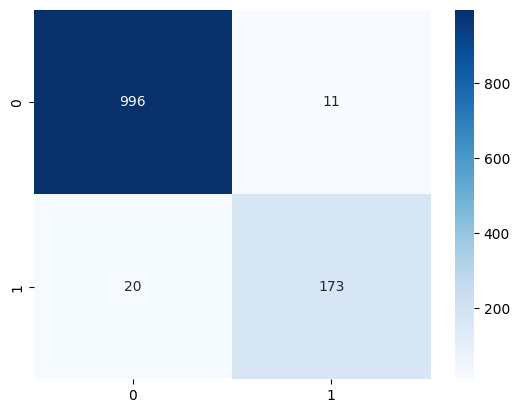

In [ ]:
print("accuracy score: ", accuracy_score(y_test, y_pred))
print("classification report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap='Blues')
plt.show()